Step 1 -In this section i set up the environment, loads the OCTMNIST dataset, and prepared it for training. I ensured reproducibility by setting random seeds and perform initial data analysis, including defining transformations and creating data loaders

In [24]:
import torch
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import medmnist
from medmnist import INFO 

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Data Loading & Preparation")
data_flag = 'octmnist'
download = True

info = INFO[data_flag]

DataClass = getattr(medmnist, data_flag.upper())

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)


BATCH_SIZE = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset: {data_flag}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

sample_input_tensor_shape = train_dataset[0][0].shape

INPUT_CHANNELS = sample_input_tensor_shape[0] 
IMAGE_SIZE_H = sample_input_tensor_shape[1] 
IMAGE_SIZE_W = sample_input_tensor_shape[2]    
 
IMAGE_SIZE = IMAGE_SIZE_H

print(f"Image dimension: ({IMAGE_SIZE_H}x{IMAGE_SIZE_W}x{INPUT_CHANNELS})") 
NUM_CLASSES = len(info['label']) 
print(f"Number of classes: {NUM_CLASSES}\n")

Data Loading & Preparation
Dataset: octmnist
Train dataset size: 97477
Validation dataset size: 10832
Test dataset size: 1000
Image dimension: (28x28x1)
Number of classes: 4



Step 2 - Here I report brief details about the nature of the dataset and include key statistics. MedMNIST datasets are generally clean, so we focus on image properties and class distribution

In [25]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

train_labels = [label.item() for _, label in train_dataset]
label_names = info['label']


sample_image_data = train_dataset[0][0].numpy() 
print("Dataset Statistics")
print(f"Sample image shape (C, H, W): {sample_image_data.shape}")
print(f"Sample image pixel min value (after trans): {sample_image_data.min():.4f}")
print(f"Sample image pixel max value (after trans): {sample_image_data.max():.4f}")
print(f"Sample image pixel mean value (after transf): {sample_image_data.mean():.4f}")
print(f"Sample image pixel std value (after trans): {sample_image_data.std():.4f}\n")

class_counts = np.bincount(train_labels)
print("Class Distribution in Training Set")
for i, count in enumerate(class_counts):
    print(f"Class {i} ({label_names[str(i)]}): {count} samples")
print(f"Total samples: {sum(class_counts)}\n")


min_class_count = np.min(class_counts)
max_class_count = np.max(class_counts)
if max_class_count / min_class_count > 1.5: 
    print("Some class imbalance")
else:
    print("Class distribution is balanced")

Dataset Statistics
Sample image shape (C, H, W): (1, 28, 28)
Sample image pixel min value (after trans): -0.9373
Sample image pixel max value (after trans): 0.1843
Sample image pixel mean value (after transf): -0.7212
Sample image pixel std value (after trans): 0.2080

Class Distribution in Training Set
Class 0 (choroidal neovascularization): 33484 samples
Class 1 (diabetic macular edema): 10213 samples
Class 2 (drusen): 7754 samples
Class 3 (normal): 46026 samples
Total samples: 97477

Some class imbalance


Step 3 - Here are three visualization graphs with short descriptions and insights to better understand the OCTMNIST dataset

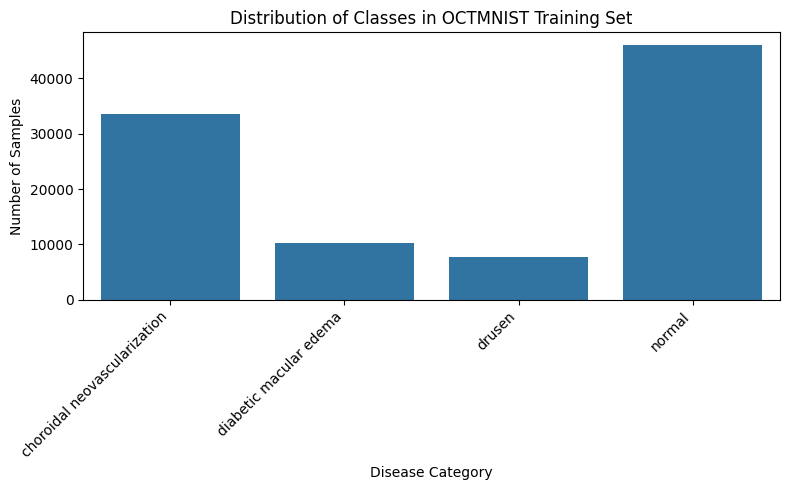

 Bar plot showing the count of samples for each disease category in the training set.


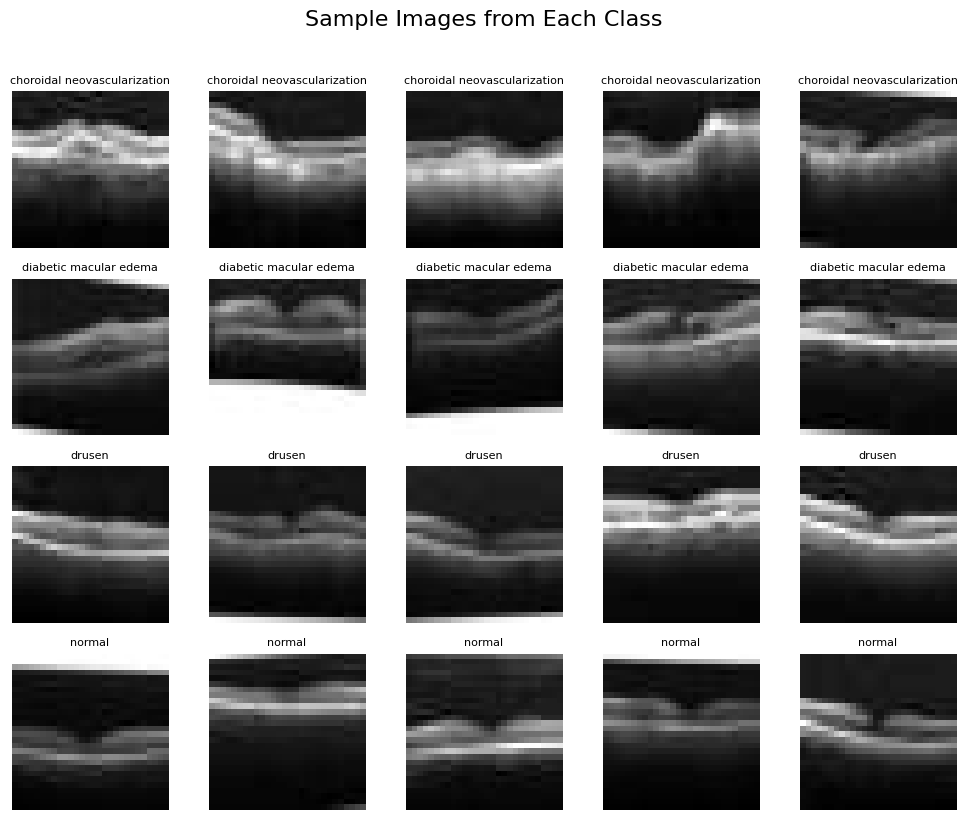

Sample images from each of the four disease classes.


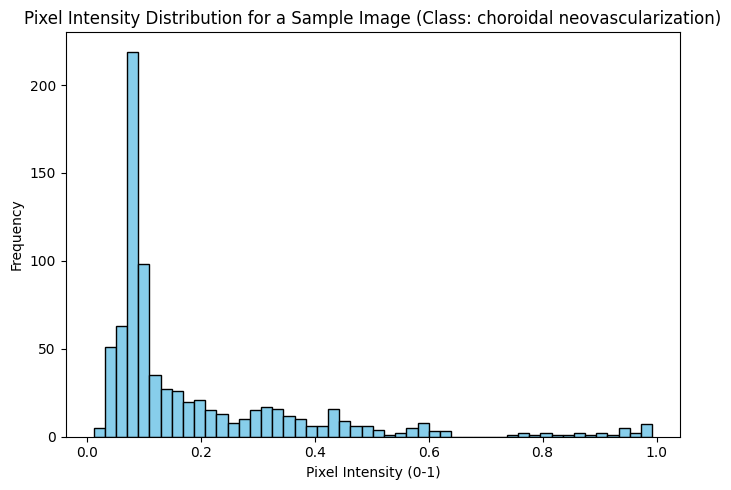

Histogram of pixel intensities for a randomly selected image.


In [26]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 


plt.figure(figsize=(8, 5))
sns.barplot(x=list(label_names.values()), y=class_counts)
plt.title('Distribution of Classes in OCTMNIST Training Set')
plt.xlabel('Disease Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(" Bar plot showing the count of samples for each disease category in the training set.")


num_samples_per_class = 5
plt.figure(figsize=(10, 2 * len(label_names)))
for i, class_name in enumerate(label_names.values()):
    class_indices = [idx for idx, label in enumerate(train_labels) if label == i]
    selected_indices = np.random.choice(class_indices, min(num_samples_per_class, len(class_indices)), replace=False)

    for j, idx in enumerate(selected_indices):
        ax = plt.subplot(len(label_names), num_samples_per_class, i * num_samples_per_class + j + 1)
        img = (train_dataset[idx][0].squeeze().numpy() * 0.5) + 0.5
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{class_name}", fontsize=8)
        ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("Sample images from each of the four disease classes.")


plt.figure(figsize=(7, 5))
random_idx = np.random.randint(0, len(train_dataset))
random_image_pixels = (train_dataset[random_idx][0].squeeze().numpy() * 0.5) + 0.5 # Denormalize for histogram if normalized to [-1, 1]
plt.hist(random_image_pixels.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.title(f'Pixel Intensity Distribution for a Sample Image (Class: {label_names[str(train_dataset[random_idx][1].item())]})')
plt.xlabel('Pixel Intensity (0-1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Histogram of pixel intensities for a randomly selected image.")


Step 4 - Data preprocessing, including pixel normalization, is handled by torchvision.transforms. The dataset is split into training, validation, and test sets using MedMNIST's predefined splits

In [27]:

print("Data Preprocessing")
print("Pixel values normalized to [-1, 1] range using transforms.ToTensor() and transforms.Normalize().")
print("Labels are already numerical (0, 1, 2, 3). No categorical conversion needed for target.")

print("Dataset Splitting")
print("Using MedMNIST's predefined train, validation, and test splits.")
print(f"Train loader has {len(train_loader)} batches of size {BATCH_SIZE}.")
print(f"Validation loader has {len(val_loader)} batches of size {BATCH_SIZE}.")
print(f"Test loader has {len(test_loader)} batches of size {BATCH_SIZE}.")

Data Preprocessing
Pixel values normalized to [-1, 1] range using transforms.ToTensor() and transforms.Normalize().
Labels are already numerical (0, 1, 2, 3). No categorical conversion needed for target.
Dataset Splitting
Using MedMNIST's predefined train, validation, and test splits.
Train loader has 762 batches of size 128.
Validation loader has 85 batches of size 128.
Test loader has 8 batches of size 128.


Step 5 - This section defines the architecture of our Convolutional Neural Network (CNN) for OCT image classification.

In [31]:
import torch
import torch.nn as nn
from torchinfo import summary 

print("\nDefining the Neural Network")

print(f"Number of input neurons (for flattened input): {IMAGE_SIZE * IMAGE_SIZE * INPUT_CHANNELS} ({IMAGE_SIZE}x{IMAGE_SIZE}x{INPUT_CHANNELS})")

print(f"Number of output neurons: {NUM_CLASSES}")

class OCTClassifierCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.5):
        super(OCTClassifierCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=INPUT_CHANNELS, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU() 
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.flatten_size = 64 * (IMAGE_SIZE // 4) * (IMAGE_SIZE // 4) 
        self.fc1 = nn.Linear(in_features=self.flatten_size, out_features=128) 
        self.relu3 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate) 

        self.fc2 = nn.Linear(in_features=128, out_features=num_classes) 

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, self.flatten_size) 
        x = self.dropout1(self.relu3(self.fc1(x)))
        x = self.fc2(x) 
        return x

model = OCTClassifierCNN(num_classes=NUM_CLASSES)
print("Defined CNN Model Architecture")
print("Hidden Layer - RelU")
print("Output Layer - Linear)")
print("Number of Convolutional Layers: 2")
print("Number of Fully Connected Layers: 2 ")
print("Size of FC Hidden Layer: 128 nodes.")
print(f"Dropout Rate {model.dropout1.p}")

print("Model Summary")

summary(model, input_size=(BATCH_SIZE, INPUT_CHANNELS, IMAGE_SIZE, IMAGE_SIZE))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"\nBase Model moved to: {device}")


Defining the Neural Network
Number of input neurons (for flattened input): 784 (28x28x1)
Number of output neurons: 4
Defined CNN Model Architecture
Hidden Layer - RelU
Output Layer - Linear)
Number of Convolutional Layers: 2
Number of Fully Connected Layers: 2 
Size of FC Hidden Layer: 128 nodes.
Dropout Rate 0.5
Model Summary

Base Model moved to: cpu


Step 6 -This section defines the loss function, optimizer, and sets up the training loop for our base CNN model.

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import time 
import os 


print("Training the Neural Network")

criterion = nn.CrossEntropyLoss()
print(f"Loss Function: {criterion.__class__.__name__} (suitable for multi-class classification)")

LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Initial Learning Rate -{LEARNING_RATE}")


NUM_EPOCHS = 30 

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}
best_val_accuracy = 0.0
BASE_MODEL_PATH = 'octmnist_cnn_base_model.pth' 

print(f"\nStarting training for Base Model for {NUM_EPOCHS} epochs")
start_time = time.time()

for epoch in range(NUM_EPOCHS):

    model.train() 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)


        outputs = model(inputs)
  
        loss = criterion(outputs, labels.squeeze().long()) 

  
        optimizer.zero_grad() 
        loss.backward()        
        optimizer.step()     

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels.squeeze()).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)


    model.eval() 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): 
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels.squeeze().long())

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels.squeeze()).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")


    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        torch.save(model.state_dict(), BASE_MODEL_PATH)
        print(f"Best base model saved at Epoch {epoch+1} with Val Acc: {best_val_accuracy:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"\nBase Model Training finished in {training_time:.2f} seconds.")


model.load_state_dict(torch.load(BASE_MODEL_PATH))
model.to(device) 

Training the Neural Network
Loss Function: CrossEntropyLoss (suitable for multi-class classification)
Optimizer: Adam
Initial Learning Rate -0.001

Starting training for Base Model for 30 epochs
Epoch 1/30 | Train Loss: 0.7518 | Train Acc: 0.7254 | Val Loss: 0.5397 | Val Acc: 0.8064
Best base model saved at Epoch 1 with Val Acc: 0.8064
Epoch 2/30 | Train Loss: 0.5426 | Train Acc: 0.8143 | Val Loss: 0.4542 | Val Acc: 0.8395
Best base model saved at Epoch 2 with Val Acc: 0.8395
Epoch 3/30 | Train Loss: 0.4809 | Train Acc: 0.8351 | Val Loss: 0.4193 | Val Acc: 0.8532
Best base model saved at Epoch 3 with Val Acc: 0.8532
Epoch 4/30 | Train Loss: 0.4423 | Train Acc: 0.8490 | Val Loss: 0.4038 | Val Acc: 0.8573
Best base model saved at Epoch 4 with Val Acc: 0.8573
Epoch 5/30 | Train Loss: 0.4154 | Train Acc: 0.8570 | Val Loss: 0.4108 | Val Acc: 0.8571
Epoch 6/30 | Train Loss: 0.3965 | Train Acc: 0.8629 | Val Loss: 0.3766 | Val Acc: 0.8676
Best base model saved at Epoch 6 with Val Acc: 0.8676
E

OCTClassifierCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

Step 7 - Model Evaluation

In [33]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns


print("Evaluating Base Model on Test Data")
model.eval() 
test_loss_base = 0.0
correct_test_base = 0
total_test_base = 0
all_labels_base = []
all_predictions_base = []
all_probabilities_base = [] 

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels.squeeze().long())

        test_loss_base += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_base.extend(labels.cpu().numpy())
        all_predictions_base.extend(predicted.cpu().numpy())
        all_probabilities_base.extend(probabilities.cpu().numpy())

        total_test_base += labels.size(0)
        correct_test_base += (predicted == labels.squeeze()).sum().item()

test_accuracy_base = correct_test_base / total_test_base
test_loss_base = test_loss_base / len(test_loader.dataset)

precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(all_labels_base, all_predictions_base, average='macro', zero_division=0)

print(f"\nBase Model Final Test Loss: {test_loss_base:.4f}")
print(f"Base Model Final Test Accuracy: {test_accuracy_base:.4f} (Expected > 75%)")
print(f"Base Model Precision (macro): {precision_base:.4f}")
print(f"Base Model Recall (macro): {recall_base:.4f}")
print(f"Base Model F1 Score (macro): {f1_base:.4f}")

if test_accuracy_base > 0.75:
    print("Base Model Test accuracy achieved the target of > 75%.")
else:
    print("Base Model Test accuracy is below the target of > 75%. Consider further optimization.")

Evaluating Base Model on Test Data

Base Model Final Test Loss: 0.9936
Base Model Final Test Accuracy: 0.7030 (Expected > 75%)
Base Model Precision (macro): 0.7870
Base Model Recall (macro): 0.7030
Base Model F1 Score (macro): 0.6629
Base Model Test accuracy is below the target of > 75%. Consider further optimization.


Step 8 - Model Visualizations 


Visualizing Base Model Results


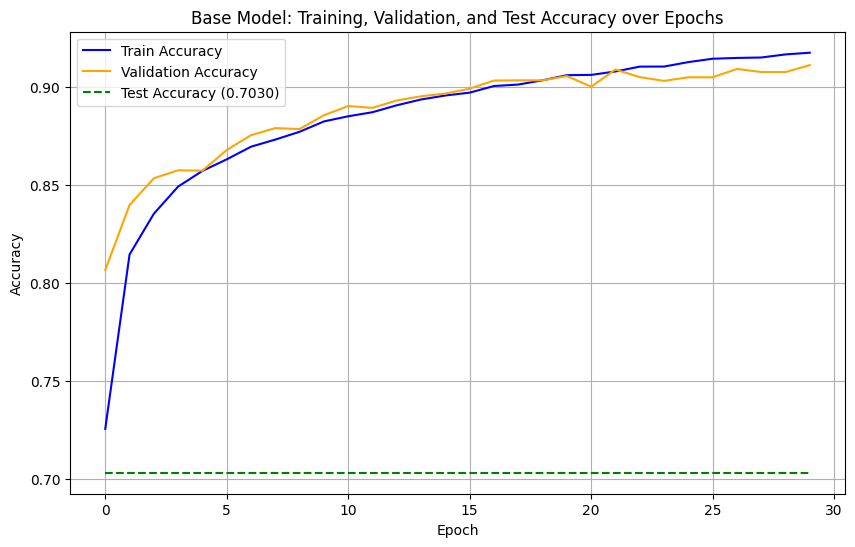

Base Model Accuracy over Epochs. Shows learning and generalization.



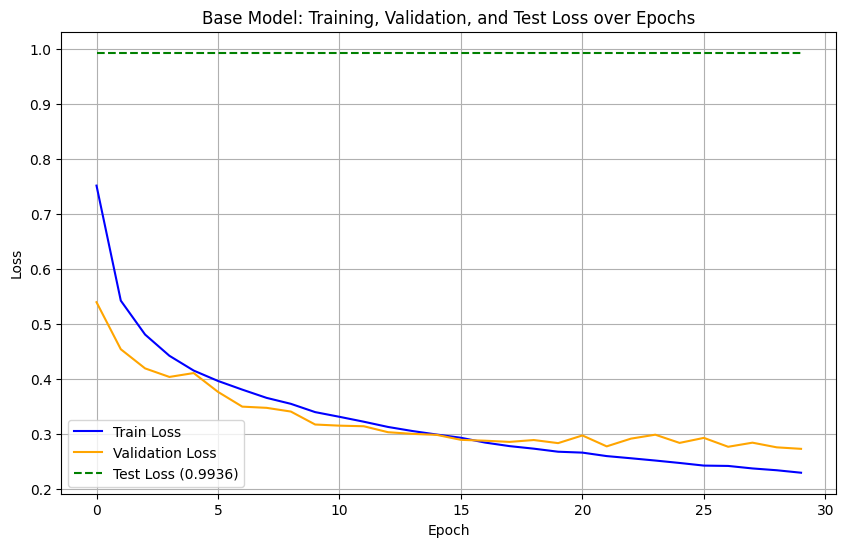

Base Model Loss over Epochs. Helps detect overfitting.



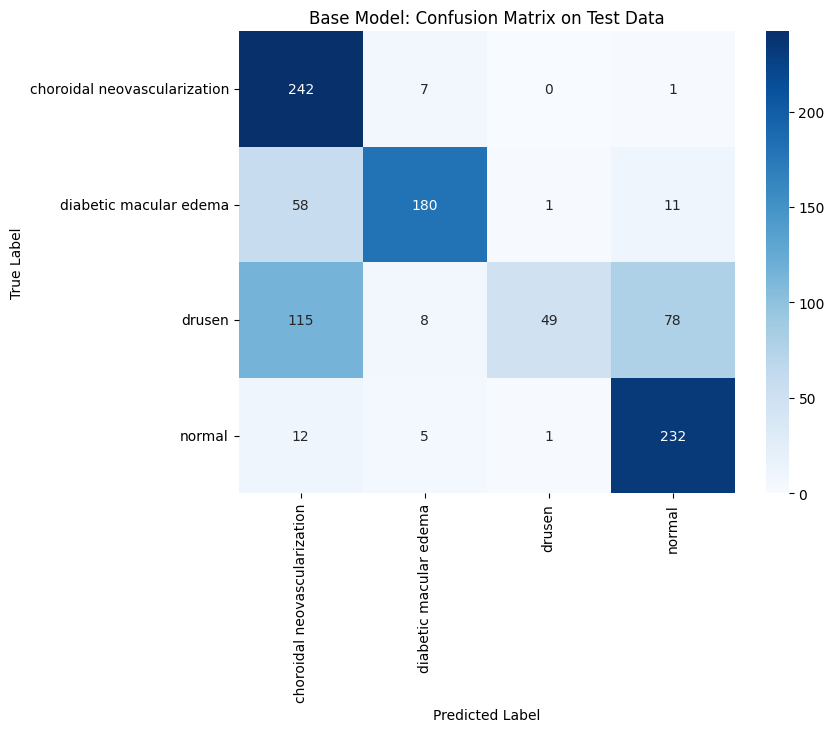

Base Model Confusion Matrix. Shows class-wise prediction accuracy.



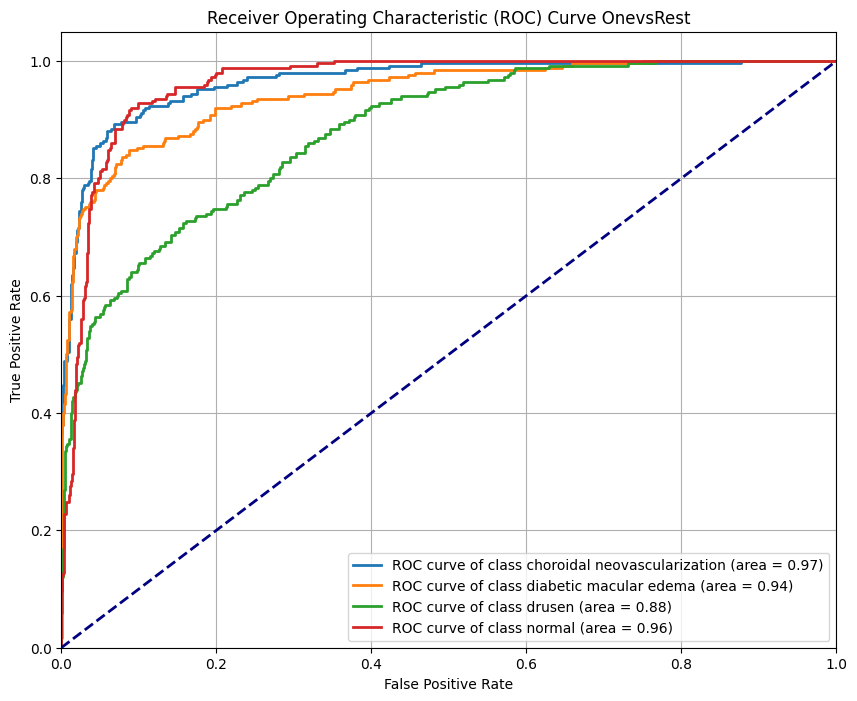

Base Model ROC Curve. Assesses multi-class classification performance.



In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


print("\nVisualizing Base Model Results")


plt.figure(figsize=(10, 6))
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
test_acc_line = [test_accuracy_base] * NUM_EPOCHS
plt.plot(test_acc_line, label=f'Test Accuracy ({test_accuracy_base:.4f})', color='green', linestyle='--')
plt.title('Base Model: Training, Validation, and Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
print("Base Model Accuracy over Epochs. Shows learning and generalization.\n")


plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Validation Loss', color='orange')
test_loss_line = [test_loss_base] * NUM_EPOCHS
plt.plot(test_loss_line, label=f'Test Loss ({test_loss_base:.4f})', color='green', linestyle='--')
plt.title('Base Model: Training, Validation, and Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
print("Base Model Loss over Epochs. Helps detect overfitting.\n")


cm_base = confusion_matrix(all_labels_base, all_predictions_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_names.values()), yticklabels=list(label_names.values()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Base Model: Confusion Matrix on Test Data')
plt.show()
print("Base Model Confusion Matrix. Shows class-wise prediction accuracy.\n")


plt.figure(figsize=(10, 8))
fpr_base = dict()
tpr_base = dict()
roc_auc_base = dict()

for i in range(NUM_CLASSES):
    fpr_base[i], tpr_base[i], _ = roc_curve(label_binarize(all_labels_base, classes=list(range(NUM_CLASSES)))[:, i], np.array(all_probabilities_base)[:, i])
    roc_auc_base[i] = auc(fpr_base[i], tpr_base[i])
    plt.plot(fpr_base[i], tpr_base[i], lw=2, label=f'ROC curve of class {label_names[str(i)]} (area = {roc_auc_base[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve OnevsRest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
print("Base Model ROC Curve. Assesses multi-class classification performance.\n")

Step 9 - Here i applied two common techniques to enhance the model's performance: a Learning Rate Scheduler and Batch Normalization.

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torchinfo import summary 


print("Improving Model Performance")

print("Implementing Learning Rate Scheduler")

print("Implementing Batch Normalization layers in the CNN architecture.")

class OCTClassifierCNNImproved(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=0.5):
        super(OCTClassifierCNNImproved, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=INPUT_CHANNELS, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) 
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.flatten_size = 64 * (IMAGE_SIZE // 4) * (IMAGE_SIZE // 4)
        self.fc1 = nn.Linear(in_features=self.flatten_size, out_features=128)
        self.bn3 = nn.BatchNorm1d(128) 
        self.relu3 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = x.view(-1, self.flatten_size)
     
        x = self.dropout1(self.relu3(self.bn3(self.fc1(x))))
        x = self.fc2(x)
        return x

improved_model = OCTClassifierCNNImproved(num_classes=NUM_CLASSES)
improved_model.to(device)

LEARNING_RATE_IMPROVED = 0.001
optimizer_improved = optim.Adam(improved_model.parameters(), lr=LEARNING_RATE_IMPROVED)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_improved, mode='min', factor=0.1, patience=5)

history_improved = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [], 'lr': []
}
best_val_accuracy_improved = 0.0
BEST_IMPROVED_MODEL_PATH = 'octmnist_cnn_improved_best_model.pth'

print(f"\nStarting training for improved model for {NUM_EPOCHS} epochs")
start_time_improved = time.time()

for epoch in range(NUM_EPOCHS):
    # Training Phase
    improved_model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_improved.zero_grad()
        outputs = improved_model(inputs)
        loss = criterion(outputs, labels.squeeze().long())
        loss.backward()
        optimizer_improved.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels.squeeze()).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    history_improved['train_loss'].append(epoch_train_loss)
    history_improved['train_acc'].append(epoch_train_acc)

    # Validation Phase
    improved_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = improved_model(inputs)
            loss = criterion(outputs, labels.squeeze().long())

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels.squeeze()).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    history_improved['val_loss'].append(epoch_val_loss)
    history_improved['val_acc'].append(epoch_val_acc)
    history_improved['lr'].append(optimizer_improved.param_groups[0]['lr']) 

    # Scheduler step
    scheduler.step(epoch_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} (Improved Model) | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {optimizer_improved.param_groups[0]['lr']:.6f}")

    if epoch_val_acc > best_val_accuracy_improved:
        best_val_accuracy_improved = epoch_val_acc
        torch.save(improved_model.state_dict(), BEST_IMPROVED_MODEL_PATH)
        print(f"Best improved model saved at Epoch {epoch+1} with Val Acc: {best_val_accuracy_improved:.4f}")

end_time_improved = time.time()
training_time_improved = end_time_improved - start_time_improved
print(f"\nImproved Model Training finished in {training_time_improved:.2f} seconds.")

Improving Model Performance
Implementing Learning Rate Scheduler
Implementing Batch Normalization layers in the CNN architecture.

Starting training for improved model for 30 epochs
Epoch 1/30 (Improved Model) | Train Loss: 0.5069 | Train Acc: 0.8240 | Val Loss: 0.5183 | Val Acc: 0.8215 | LR: 0.001000
Best improved model saved at Epoch 1 with Val Acc: 0.8215
Epoch 2/30 (Improved Model) | Train Loss: 0.3838 | Train Acc: 0.8674 | Val Loss: 0.3521 | Val Acc: 0.8784 | LR: 0.001000
Best improved model saved at Epoch 2 with Val Acc: 0.8784
Epoch 3/30 (Improved Model) | Train Loss: 0.3425 | Train Acc: 0.8798 | Val Loss: 0.3396 | Val Acc: 0.8772 | LR: 0.001000
Epoch 4/30 (Improved Model) | Train Loss: 0.3130 | Train Acc: 0.8904 | Val Loss: 0.3377 | Val Acc: 0.8797 | LR: 0.001000
Best improved model saved at Epoch 4 with Val Acc: 0.8797
Epoch 5/30 (Improved Model) | Train Loss: 0.2917 | Train Acc: 0.8989 | Val Loss: 0.3418 | Val Acc: 0.8834 | LR: 0.001000
Best improved model saved at Epoch 5 wi